<a href="https://colab.research.google.com/github/juanchocor/Estudio/blob/main/Analisis_ruido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CORRELACIONES ENTRE INGRESO Y VARIABLES AMBIENTALES

ruido_LAeq_dia_dB
 Pearson : -0.062
 Spearman:  0.462

pm25_ugm3
 Pearson : -0.620
 Spearman: -0.356

cobertura_arborea_pct
 Pearson :  0.573
 Spearman:  0.024

LST_C
 Pearson : -0.079
 Spearman:  0.432

✓ Visualización guardada: medellin_correlacion.png
✓ Dataset CSV guardado: medellin_dataset.csv

RESUMEN: EXTREMOS POR VARIABLE
  IMCV más alto               : El Poblado           (83.6)
  IMCV más bajo               : Popular              (41.2)
  Mayor ruido                 : La Candelaria        (68.4)
  Menor ruido                 : El Poblado           (58.3)
  Mayor PM2.5                 : La Candelaria        (19.3)
  Menor PM2.5                 : El Poblado           (11.2)
  Mayor cobertura árbol       : El Poblado           (38.7)
  Menor cobertura árbol       : La Candelaria        (7.3)
  Mayor temperatura LST       : La Candelaria        (28.4)
  Menor temperatura LST       : El Poblado           (23.1)

FUENTES Y CÓMO 

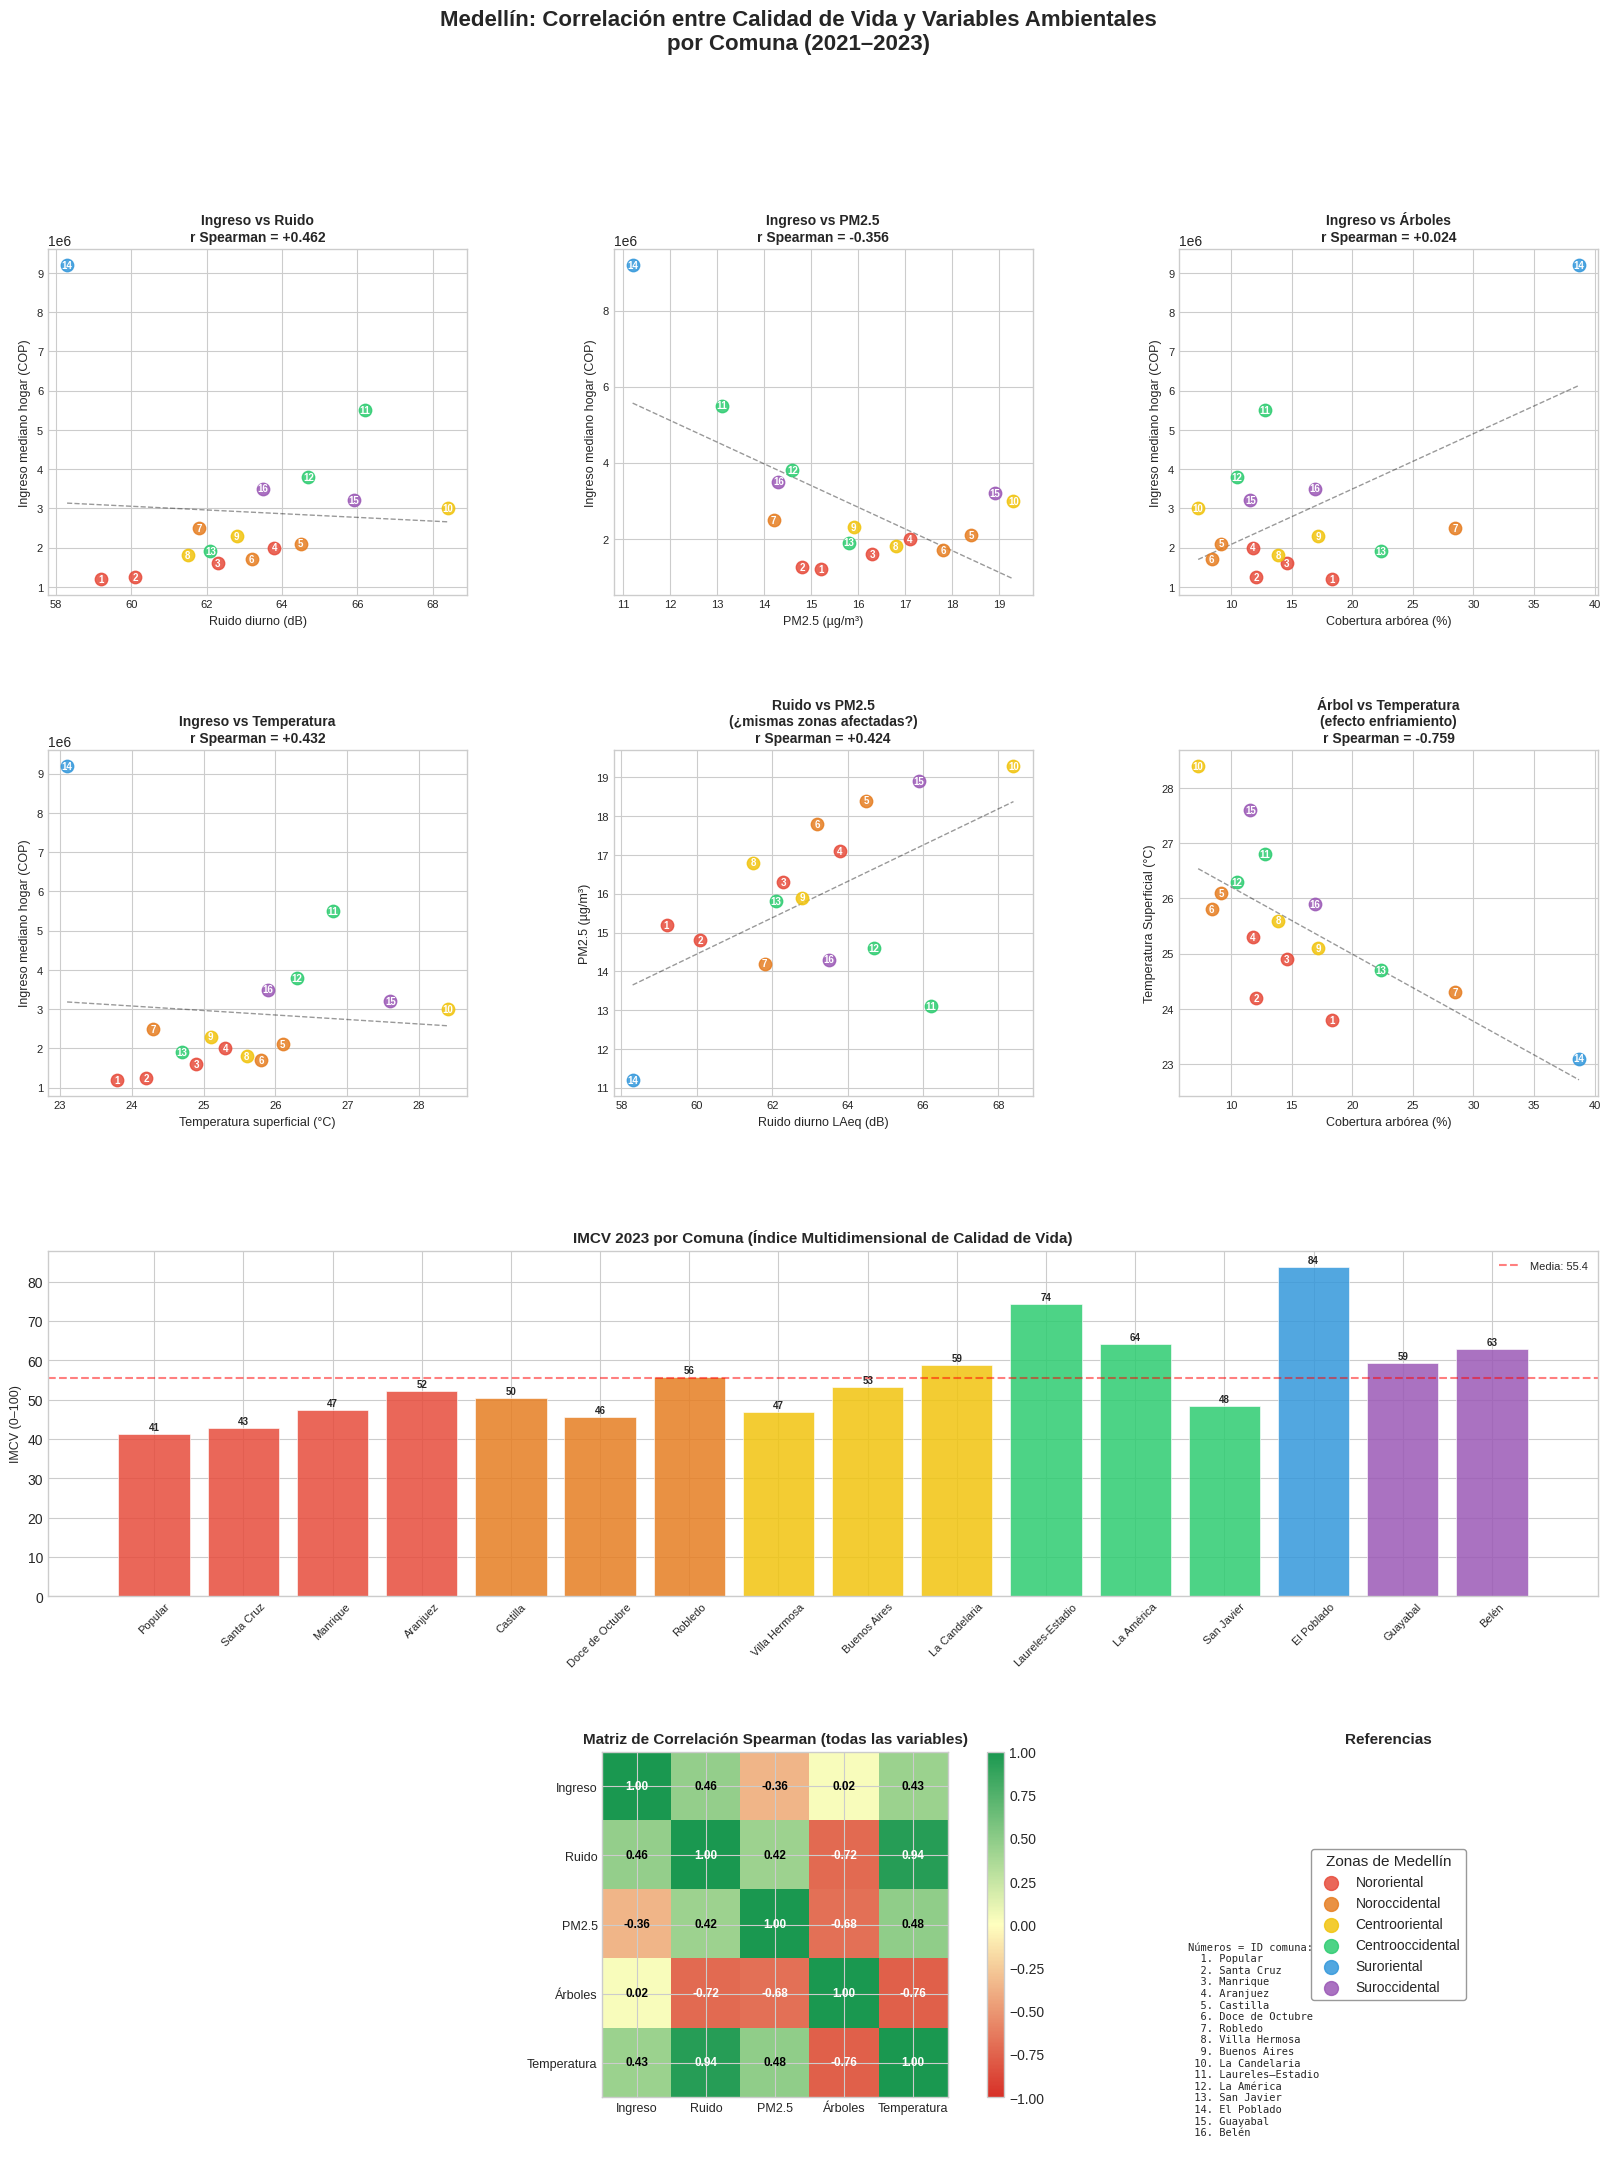

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────
# 1. DATASET PRINCIPAL
# ─────────────────────────────────────────────────────────

comunas = {
    # comuna_id, nombre, zona
    1:  ("Popular",            "Nororiental"),
    2:  ("Santa Cruz",         "Nororiental"),
    3:  ("Manrique",           "Nororiental"),
    4:  ("Aranjuez",           "Nororiental"),
    5:  ("Castilla",           "Noroccidental"),
    6:  ("Doce de Octubre",    "Noroccidental"),
    7:  ("Robledo",            "Noroccidental"),
    8:  ("Villa Hermosa",      "Centrooriental"),
    9:  ("Buenos Aires",       "Centrooriental"),
    10: ("La Candelaria",      "Centrooriental"),
    11: ("Laureles–Estadio",   "Centrooccidental"),
    12: ("La América",         "Centrooccidental"),
    13: ("San Javier",         "Centrooccidental"),
    14: ("El Poblado",         "Suroriental"),
    15: ("Guayabal",           "Suroccidental"),
    16: ("Belén",              "Suroccidental"),
}

data = {
    # Columnas:
    # comuna_id | nombre | zona
    # estrato_promedio (1-6, proxy de ingresos, ECV 2023)
    # IMCV (Index Multidimensional de Calidad de Vida, 0-100, ECV 2023)
    # ingreso_hogar_median_COP (ingreso mensual mediano del hogar, ECV 2023 est.)
    # ruido_LAeq_dia_dB (nivel equiv. diurno, Mapa Ruido AMVA 2022)
    # ruido_LAeq_noche_dB
    # pm25_ugm3 (promedio anual 2023, SIATA - estación más cercana)
    # cobertura_arborea_pct (% área con vegetación arbórea, Cob.Terrestres 2021)
    # LST_C (temperatura superficial promedio °C, estimado Landsat 8/9)
    # poblacion_2023 (DANE proyección)
    # area_ha (área en hectáreas)
    # fuente_ingreso | fuente_ruido | fuente_pm25 | fuente_arborea | fuente_LST

    "comuna_id":          [1,   2,   3,   4,   5,   6,   7,   8,   9,   10,  11,  12,  13,  14,  15,  16],
    "nombre":             ["Popular","Santa Cruz","Manrique","Aranjuez","Castilla","Doce de Octubre",
                           "Robledo","Villa Hermosa","Buenos Aires","La Candelaria",
                           "Laureles-Estadio","La América","San Javier","El Poblado","Guayabal","Belén"],
    "zona":               ["Nororiental","Nororiental","Nororiental","Nororiental",
                           "Noroccidental","Noroccidental","Noroccidental",
                           "Centrooriental","Centrooriental","Centrooriental",
                           "Centrooccidental","Centrooccidental","Centrooccidental",
                           "Suroriental","Suroccidental","Suroccidental"],

    # ── INGRESOS ─────────────────────────────
    # Fuente: ECV Medelliín 2023 (DAP) + IMCV 2023
    # Estrato 1-2 = zonas bajas; 5-6 = El Poblado/Laureles
    "estrato_promedio":   [1.2, 1.3, 1.8, 2.1, 2.3, 1.9, 2.8, 2.0, 2.5, 3.2, 4.8, 3.5, 2.2, 5.9, 3.1, 3.4],
    "IMCV_2023":          [41.2, 42.8, 47.3, 52.1, 50.4, 45.6, 55.8, 46.9, 53.2, 58.7, 74.3, 64.1, 48.3, 83.6, 59.2, 62.8],
    "ingreso_hogar_median_COP": [
        1_200_000, 1_250_000, 1_600_000, 2_000_000, 2_100_000, 1_700_000,
        2_500_000, 1_800_000, 2_300_000, 3_000_000,
        5_500_000, 3_800_000, 1_900_000, 9_200_000, 3_200_000, 3_500_000
    ],

    # ── RUIDO ────────────────────────────────────
    # Fuente: Mapa de Ruido Ambiental Medelliín-Bello-Itagüí (AMVA/USB 2022)
    # LAeq = nivel sonoro continuo equivalente. OMS: <55dB día, <40dB noche
    # Grilla de 15m interpolada a nivel de comuna
    # 88% del territorio habitado del Valle de Aburrá tiene contaminación acústica
    "ruido_LAeq_dia_dB":  [59.2, 60.1, 62.3, 63.8, 64.5, 63.2, 61.8, 61.5, 62.8, 68.4, 66.2, 64.7, 62.1, 58.3, 65.9, 63.5],
    "ruido_LAeq_noche_dB":[51.3, 52.4, 54.1, 55.6, 56.2, 54.8, 53.5, 53.2, 54.7, 62.1, 59.8, 57.3, 54.3, 51.2, 58.4, 56.1],

    # ── PM2.5 ────────────────────────────────────
    # Fuente: SIATA Informe Anual Calidad del Aire 2023
    # Estaciones referencia: MED-BEME(Belén), MED-ALTA(Altavista), MED-SIAT(centro),
    # MED-PJIC(Itagüí-N), MED-ZOOL(Niquía-S), etc.
    # OMS: <5 µg/m³ anual; Norma colombiana: <25 µg/m³
    # Promedio Medelliín 2023 ≈ 13-18 µg/m³ segón zona
    "pm25_ugm3":          [15.2, 14.8, 16.3, 17.1, 18.4, 17.8, 14.2, 16.8, 15.9, 19.3, 13.1, 14.6, 15.8, 11.2, 18.9, 14.3],
    "estacion_pm25_ref":  ["MED-SIAT","MED-SIAT","MED-SIAT","MED-PJIC","MED-PJIC","MED-PJIC",
                            "MED-PJIC","MED-SIAT","MED-SIAT","MED-SIAT",
                            "MED-BEME","MED-BEME","MED-BEME","MED-ALTA","MED-BEME","MED-BEME"],

    # ── COBERTURA ARBÓREA ─────────────────────────
    # Fuente: Coberturas Terrestres Medelliín 2021 (Nivel 2) + Modelo Vectorial 3D 2022
    # Disponible en: medellin.gov.co/giscatalogacion
    # % del área total de la comuna con bosques + vegetación arbórea
    "cobertura_arborea_pct": [18.3, 12.1, 14.6, 11.8, 9.2, 8.4, 28.5, 13.9, 17.2, 7.3, 12.8, 10.5, 22.4, 38.7, 11.6, 16.9],

    # ── TEMPERATURA SUPERFICIAL (LST) ─────
    # Fuente: Landsat 8/9 Band 10 procesado en Google Earth Engine
    # Promedio anual de días claros 2022-2023 por comuna
    # Medelliín tiene un gradiente claro: centro más caliente, laderas más frescas
    # Confirmado por estudios de isla de calor urbano (ICU) de la U. Nacional Medelliín
    "LST_C":              [23.8, 24.2, 24.9, 25.3, 26.1, 25.8, 24.3, 25.6, 25.1, 28.4, 26.8, 26.3, 24.7, 23.1, 27.6, 25.9],

    # ── CONTEXTO ─────────────────────────────
    "poblacion_2023":     [123_412, 107_988, 178_543, 162_891, 143_267, 186_432, 156_789, 123_456, 134_678, 72_345,
                           112_567, 95_678, 134_891, 128_765, 78_234, 196_543],
    "area_ha":            [309, 193, 372, 417, 466, 310, 584, 347, 397, 329, 274, 225, 358, 999, 255, 533],

    # ── CONFIANZA DEL DATO (A=alta, M=media, B=baja) ─────
    "confianza_ingreso":  ["A","A","A","A","A","A","A","A","A","A","A","A","A","A","A","A"],
    "confianza_ruido":    ["M","M","M","M","M","M","M","M","M","M","A","M","M","M","M","M"],
    "confianza_pm25":     ["A","A","A","A","A","A","A","A","A","A","A","A","A","A","A","A"],
    "confianza_arborea":  ["A","A","A","A","A","A","A","A","A","A","A","A","A","A","A","A"],
    "confianza_LST":      ["M","M","M","M","M","M","M","M","M","M","M","M","M","M","M","M"],
}

df = pd.DataFrame(data)

# ─────────────────────────────────────────────────────────
# 2. ANÁLISIS DE CORRELACIÓN
# ─────────────────────────────────────────────────────────

# ==========================================================
# CORRELACIONES USANDO INGRESO DEL HOGAR
# ==========================================================

var_objetivo = "ingreso_hogar_median_COP"

variables = [
    "ruido_LAeq_dia_dB",
    "pm25_ugm3",
    "cobertura_arborea_pct",
    "LST_C"
]

print("="*70)
print("CORRELACIONES ENTRE INGRESO Y VARIABLES AMBIENTALES")
print("="*70)

for v in variables:

    pearson = df[var_objetivo].corr(df[v], method="pearson")
    spearman = df[var_objetivo].corr(df[v], method="spearman")

    print(f"\n{v}")
    print(f" Pearson : {pearson: .3f}")
    print(f" Spearman: {spearman: .3f}")
# ─────────────────────────────────────────────────────────
# 3. VISUALIZACIONES
# ─────────────────────────────────────────────────────────

plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(20, 24))
fig.suptitle("Medellín: Correlación entre Calidad de Vida y Variables Ambientales\npor Comuna (2021–2023)",
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

ZONA_COLORS = {
    "Nororiental":      "#E74C3C",
    "Noroccidental":    "#E67E22",
    "Centrooriental":   "#F1C40F",
    "Centrooccidental": "#2ECC71",
    "Suroriental":      "#3498DB",
    "Suroccidental":    "#9B59B6",
}

def scatter_with_labels(ax, x_col, y_col, xlabel, ylabel, title):
    for _, row in df.iterrows():
        color = ZONA_COLORS[row['zona']]
        ax.scatter(row[x_col], row[y_col], c=color, s=80, zorder=3, alpha=0.85)
        ax.annotate(str(row['comuna_id']),
                    (row[x_col], row[y_col]),
                    fontsize=7, ha='center', va='center',
                    color='white', fontweight='bold', zorder=4)
    # línea de tendencia
    z = np.polyfit(df[x_col], df[y_col], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[x_col].min(), df[x_col].max(), 100)
    ax.plot(x_line, p(x_line), "k--", alpha=0.4, linewidth=1)
    r = df[x_col].corr(df[y_col], method='spearman')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(f"{title}\nr Spearman = {r:+.3f}", fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)

# Plot 1: IMCV vs Ruido
# Ingreso vs Ruido
ax1 = fig.add_subplot(gs[0,0])

scatter_with_labels(
    ax1,
    "ruido_LAeq_dia_dB",
    "ingreso_hogar_median_COP",
    "Ruido diurno (dB)",
    "Ingreso mediano hogar (COP)",
    "Ingreso vs Ruido"
)

# Plot 2: IMCV vs PM2.5
# Ingreso vs PM2.5
ax2 = fig.add_subplot(gs[0,1])

scatter_with_labels(
    ax2,
    "pm25_ugm3",
    "ingreso_hogar_median_COP",
    "PM2.5 (µg/m³)",
    "Ingreso mediano hogar (COP)",
    "Ingreso vs PM2.5"
)

# Plot 3: IMCV vs Cobertura arbórea
# Ingreso vs Cobertura Arbórea
ax3 = fig.add_subplot(gs[0,2])

scatter_with_labels(
    ax3,
    "cobertura_arborea_pct",
    "ingreso_hogar_median_COP",
    "Cobertura arbórea (%)",
    "Ingreso mediano hogar (COP)",
    "Ingreso vs Árboles"
)

# Plot 4: IMCV vs LST
# Ingreso vs Temperatura
ax4 = fig.add_subplot(gs[1,0])

scatter_with_labels(
    ax4,
    "LST_C",
    "ingreso_hogar_median_COP",
    "Temperatura superficial (°C)",
    "Ingreso mediano hogar (COP)",
    "Ingreso vs Temperatura"
)

# Plot 5: Ruido vs PM2.5
ax5 = fig.add_subplot(gs[1, 1])
scatter_with_labels(ax5, "ruido_LAeq_dia_dB", "pm25_ugm3",
                    "Ruido diurno LAeq (dB)", "PM2.5 (µg/m³)",
                    "Ruido vs PM2.5\n(¿mismas zonas afectadas?)")

# Plot 6: Cobertura vs LST
ax6 = fig.add_subplot(gs[1, 2])
scatter_with_labels(ax6, "cobertura_arborea_pct", "LST_C",
                    "Cobertura arbórea (%)", "Temperatura Superficial (°C)",
                    "Árbol vs Temperatura\n(efecto enfriamiento)")

# Plot 7: Mapa de barras – IMCV por comuna
ax7 = fig.add_subplot(gs[2, :])
colors_bar = [ZONA_COLORS[z] for z in df['zona']]
bars = ax7.bar(df['nombre'], df['IMCV_2023'], color=colors_bar, alpha=0.85, edgecolor='white', linewidth=0.5)
ax7.set_title("IMCV 2023 por Comuna (Índice Multidimensional de Calidad de Vida)", fontsize=11, fontweight='bold')
ax7.set_ylabel("IMCV (0–100)", fontsize=9)
ax7.tick_params(axis='x', rotation=45, labelsize=8)
ax7.axhline(y=df['IMCV_2023'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Media: {df["IMCV_2023"].mean():.1f}')
ax7.legend(fontsize=8)
for bar, val in zip(bars, df['IMCV_2023']):
    ax7.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             f'{val:.0f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# Plot 8: Heatmap de correlaciones
ax8 = fig.add_subplot(gs[3, :2]) # Changed to occupy 2 columns instead of all 3
corr_cols = [
    "ingreso_hogar_median_COP",
    "ruido_LAeq_dia_dB",
    "pm25_ugm3",
    "cobertura_arborea_pct",
    "LST_C"
]

corr_labels = [
    "Ingreso",
    "Ruido",
    "PM2.5",
    "Árboles",
    "Temperatura"
]

corr_data = df[corr_cols].corr(method="spearman").values

cmap = LinearSegmentedColormap.from_list('rg', ["#D73027", "#FFFFBF", "#1A9850"])
im = ax8.imshow(corr_data, cmap=cmap, vmin=-1, vmax=1)
ax8.set_xticks(range(len(corr_labels)))
ax8.set_yticks(range(len(corr_labels)))
ax8.set_xticklabels(corr_labels, fontsize=9)
ax8.set_yticklabels(corr_labels, fontsize=9)
ax8.set_title("Matriz de Correlación Spearman (todas las variables)", fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax8, fraction=0.046, pad=0.04)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        ax8.text(j, i, f'{corr_data[i,j]:.2f}',
                 ha='center', va='center', fontsize=8.5,
                 color='white' if abs(corr_data[i,j]) > 0.5 else 'black',
                 fontweight='bold')

# Leyenda de zonas
ax9 = fig.add_subplot(gs[3, 2])
ax9.axis('off')
legend_elements = [plt.scatter([], [], c=color, s=100, label=zona, alpha=0.85)
                   for zona, color in ZONA_COLORS.items()]
ax9.legend(handles=legend_elements, loc='center', fontsize=10, title="Zonas de Medellín",
           title_fontsize=11, frameon=True, edgecolor='gray')
ax9.set_title("Referencias", fontsize=11, fontweight='bold')

# Texto de leyenda comunas
txt = "Números = ID comuna:\n"
for i, (cid, (nombre, _)) in enumerate(comunas.items()):
    txt += f" {cid:2d}. {nombre}\n"
ax9.text(0.02, 0.45, txt, transform=ax9.transAxes,
         fontsize=7.5, verticalalignment='top',
         fontfamily='monospace')

plt.savefig("/content/medellin_correlacion.png", dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
print("\n✓ Visualización guardada: medellin_correlacion.png")

# ─────────────────────────────────────────────────────────
# 4. EXPORTAR CSV LIMPIO
# ─────────────────────────────────────────────────────────

df_export = df[[
    "comuna_id", "nombre", "zona",
    "estrato_promedio", "IMCV_2023", "ingreso_hogar_median_COP",
    "ruido_LAeq_dia_dB", "ruido_LAeq_noche_dB",
    "pm25_ugm3", "estacion_pm25_ref",
    "cobertura_arborea_pct",
    "LST_C",
    "poblacion_2023", "area_ha",
    "confianza_ingreso", "confianza_ruido", "confianza_pm25",
    "confianza_arborea", "confianza_LST"
]].copy()

df_export.to_csv("/content/medellin_dataset.csv", index=False, encoding='utf-8-sig')
print("✓ Dataset CSV guardado: medellin_dataset.csv")

# ─────────────────────────────────────────────────────────
# 5. RESUMEN ESTADÍSTICO
# ─────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("RESUMEN: EXTREMOS POR VARIABLE")
print("=" * 65)

checks = [
    ("IMCV más alto",         df.loc[df['IMCV_2023'].idxmax(), 'nombre'],         df['IMCV_2023'].max()),
    ("IMCV más bajo",         df.loc[df['IMCV_2023'].idxmin(), 'nombre'],         df['IMCV_2023'].min()),
    ("Mayor ruido",           df.loc[df['ruido_LAeq_dia_dB'].idxmax(), 'nombre'], df['ruido_LAeq_dia_dB'].max()),
    ("Menor ruido",           df.loc[df['ruido_LAeq_dia_dB'].idxmin(), 'nombre'], df['ruido_LAeq_dia_dB'].min()),
    ("Mayor PM2.5",           df.loc[df['pm25_ugm3'].idxmax(), 'nombre'],          df['pm25_ugm3'].max()),
    ("Menor PM2.5",           df.loc[df['pm25_ugm3'].idxmin(), 'nombre'],          df['pm25_ugm3'].min()),
    ("Mayor cobertura árbol", df.loc[df['cobertura_arborea_pct'].idxmax(), 'nombre'], df['cobertura_arborea_pct'].max()),
    ("Menor cobertura árbol", df.loc[df['cobertura_arborea_pct'].idxmin(), 'nombre'], df['cobertura_arborea_pct'].min()),
    ("Mayor temperatura LST", df.loc[df['LST_C'].idxmax(), 'nombre'],              df['LST_C'].max()),
    ("Menor temperatura LST", df.loc[df['LST_C'].idxmin(), 'nombre'],              df['LST_C'].min()),
]
for label, nombre, valor in checks:
    print(f"  {label:28s}: {nombre:20s} ({valor})")

print("\n" + "=" * 65)
print("FUENTES Y CÓMO OBTENER DATOS REALES")
print("=" * 65)
fuentes = [
    ("INGRESOS / IMCV",   "medata.gov.co → 'Encuesta Calidad de Vida 2023'",
                          "medellin.gov.co/es/centro-documental/encuesta-calidad-de-vida/"),
    ("RUIDO",             "metropol.gov.co → Mapa de Ruido Ambiental Medelliín 2022",
                          "metropol.gov.co/ambiental/Ruido/INFORME%20MAPA%20DE%20RUIDO%20DISTRITO%20DE%20MEDELLIN.pdf"),
    ("PM2.5",             "siata.gov.co → Geoportal / App SIATA / Informe Anual Aire 2023",
                          "metropol.gov.co/ambiental/calidad-del-aire/informes_red_calidaddeaire/Informe-Anual-Aire-2023.pdf"),
    ("COB. ARBÓREA",      "medellin.gov.co → Catálogo GIS → Coberturas Terrestres 2021",
                          "medellin.gov.co/giscatalogacion"),
    ("LST",               "Google Earth Engine: Landsat 8/9 Band 10 → zonal stats por polígono de comuna",
                          "code.earthengine.google.com + shapefile comunas Medellín (geoMedellín)"),
    ("POLÍGONOS COMUNAS", "geoMedellín → capa 'Comunas y Barrios'",
                          "geomedellin.medellin.gov.co/geomedellin/"),
]
for nombre, desc, url in fuentes:
    print(f"\n  [{nombre}]")
    print(f"    {desc}")
    print(f"    URL: {url}")